In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

#load data
housing = fetch_california_housing()
df_house = pd.DataFrame(housing.data, columns=housing.feature_names)
df_house['Price'] = housing.target
df_house.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


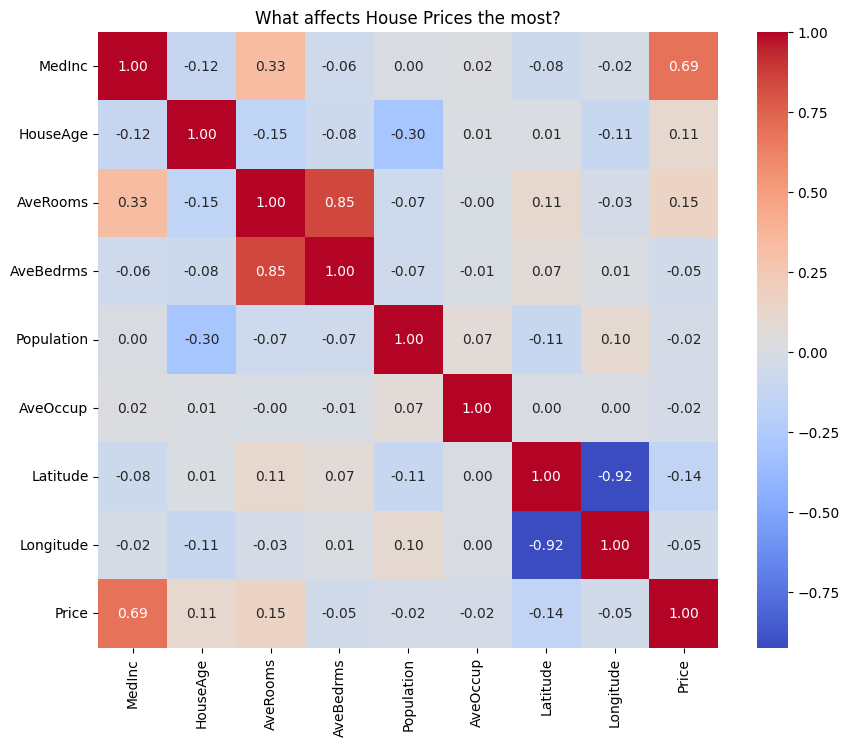

In [ ]:
#Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df_house.corr(),annot=True, cmap='coolwarm',fmt='.2f')
plt.title("What affects House Prices the most?")
plt.show()

In [ ]:
#training the regressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

#1. Define X and y
X = df_house.drop('Price', axis=1)
y = df_house['Price']

#2. Split data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

#3. Train model
house_model = LinearRegression()
house_model.fit(X_train, y_train)

#4. predict
predictions = house_model.predict(X_test)

#5. Evaluate
print(f"R2 Score (Accuracy of fit): {r2_score(y_test,predictions):.4f}")
print(f"Mean Error: ${mean_absolute_error(y_test, predictions)* 10000:.2f}")

R2 Score (Accuracy of fit): 0.5758
Mean Error: $5332.00
